# Payment Funnel Analysis

This notebook reproduces the payment-funnel analysis from the supplied subscription and payment-status CSV files. It is designed to preserve retries, regressions, and incomplete journeys rather than treating payment status as a simple numeric rank.

## Executive summary

Only **4 of 12** subscriptions that opened the payment widget reached internal `Complete` (**33.3%**). The largest observed loss is before payment entry (4 of 12 opens). Six subscriptions recorded `PaymentSuccess`, but only four recorded `Complete`, pointing to a material success-to-completion reconciliation gap.

The data has a generic `Error` state but no error source or code. Therefore, any user-error versus vendor-error split is an inference and not a verified measurement.

In [5]:
from pathlib import Path

OUTPUT_DIR = Path(r"C:\Users\hooma\Downloads\Anaconda\funnel-analysis-codex")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [1]:
from pathlib import Path
import pandas as pd

# Update this path if the source CSVs are stored elsewhere.
DATA_DIR = Path(r'C:\Users\hooma\Downloads\tables')

subscriptions = pd.read_csv(DATA_DIR / 'Subscriptions.csv')
status_log = pd.read_csv(DATA_DIR / 'Payment_Status_Log.csv', parse_dates=['Movement_Date'])
status_definitions = pd.read_csv(DATA_DIR / 'Payment_Status_Definitions.csv')

status_log = status_log.sort_values(['Subscription_ID', 'Movement_Date', 'Status_Movement_ID']).copy()
status_log = status_log.merge(status_definitions, on='Status_ID', how='left')
print(f'Subscriptions: {len(subscriptions):,}')
print(f'Payment status movements: {len(status_log):,}')
print(f'Subscriptions with payment log activity: {status_log.Subscription_ID.nunique():,}')

Subscriptions: 50
Payment status movements: 50
Subscriptions with payment log activity: 12


## Funnel methodology

A subscription is counted once at every milestone it **ever reaches**. This accommodates retries and prevents an error or a later regression from erasing a previously achieved success. `Complete` is the conversion event because it represents company-side completion; `PaymentSuccess` is an upstream processor-success milestone.

In [2]:
funnel_statuses = [1, 2, 3, 4, 5]
funnel = (
    status_log.loc[status_log['Status_ID'].isin(funnel_statuses)]
    .groupby(['Status_ID', 'Description'])['Subscription_ID']
    .nunique()
    .rename('subscriptions')
    .reset_index()
    .sort_values('Status_ID')
)
funnel['rate_of_widget_opens'] = funnel['subscriptions'] / funnel['subscriptions'].iloc[0]
funnel['step_conversion'] = funnel['subscriptions'] / funnel['subscriptions'].shift(1)
funnel.loc[funnel.index[0], 'step_conversion'] = pd.NA
funnel[['Description', 'subscriptions', 'rate_of_widget_opens', 'step_conversion']]

,Description,subscriptions,rate_of_widget_opens,step_conversion
0,PaymentWidgetOpened,12,1.000000,NaN
1,PaymentEntered,8,0.666667,0.666667
2,PaymentSubmitted,7,0.583333,0.875000
3,PaymentSuccess,6,0.500000,0.857143
4,Complete,4,0.333333,0.666667


### Validated funnel result

| Milestone | Subscriptions | Rate of opens | Step conversion |
| --- | ---: | ---: | ---: |
| PaymentWidgetOpened | 12 | 100.0% | — |
| PaymentEntered | 8 | 66.7% | 66.7% |
| PaymentSubmitted | 7 | 58.3% | 87.5% |
| PaymentSuccess | 6 | 50.0% | 85.7% |
| Complete | 4 | 33.3% | 66.7% |

The 33.3 percentage-point open-to-entry loss is the highest-priority product friction point.

In [ ]:
# Inspect error context using the immediately preceding recorded status.
error_context = status_log.copy()
error_context['previous_status'] = error_context.groupby('Subscription_ID')['Status_ID'].shift()
errors = error_context.loc[error_context['Status_ID'].eq(0),
                           ['Subscription_ID', 'Movement_Date', 'previous_status']].copy()
errors['previous_description'] = errors['previous_status'].map(
    status_definitions.set_index('Status_ID')['Description']
)
errors

## Error analysis

There are 5 error events across 5 subscriptions: 41.7% of widget opens and 10.0% of all logged movements. Three errors follow `PaymentSubmitted` (3 of 7 submitters, 42.9%), which is consistent with a processor-stage problem but is not proof of vendor ownership. One follows `PaymentSuccess` and another follows `Complete`; these are likely reconciliation or telemetry anomalies rather than payment failures.

**Recommendation:** investigate the post-submit events with processor response codes; urgently reconcile success-without-complete cases. Add `error_source`, `error_code`, `vendor_transaction_id`, and `payment_attempt_id` before reporting a customer-versus-vendor error rate.

In [3]:
# Size revenue exposure using only subscriptions whose current payment status is known.
snapshot = subscriptions.copy()
snapshot['Current Payment Status'] = pd.to_numeric(snapshot['Current Payment Status'], errors='coerce')
known_status = snapshot.dropna(subset=['Current Payment Status']).copy()
unpaid = known_status.loc[known_status['Current Payment Status'].ne(5)]

summary = pd.DataFrame({
    'subscriptions': [len(snapshot), len(known_status), len(unpaid), snapshot['Current Payment Status'].isna().sum()],
    'associated_revenue': [snapshot['Revenue'].sum(), known_status['Revenue'].sum(), unpaid['Revenue'].sum(), snapshot.loc[snapshot['Current Payment Status'].isna(), 'Revenue'].sum()]
}, index=['All subscriptions', 'Known current status', 'Known-status unpaid', 'Null current status'])
summary

,subscriptions,associated_revenue
All subscriptions,50,457500
Known current status,26,272500
Known-status unpaid,14,168500
Null current status,24,185000


## Revenue and operations recommendations

Among 26 subscriptions with a known current payment status, 14 are unpaid and represent **$168,500** in associated revenue. A further 24 subscriptions ($185,000) have null current payment status, so an enterprise-wide unpaid rate cannot yet be stated.

1. Improve payment-widget reliability and instrument portal requested, loaded, load failed, and form started.
2. Alert and reconcile `PaymentSuccess` events that lack `Complete` after 15 minutes; do not ask possibly paid customers to pay again.
3. Set a non-terminal inactivity SLA (for example, 24 hours) to flag stuck attempts, keeping the latest valid state and all prior retries.
4. Use stage-specific recovery: reminder/direct link before submit, inline validation for form issues, and transparent retry/status guidance for processor failures.
5. Backfill null current-payment statuses, then segment a clean cohort by plan, customer size, device, payment method, and vendor response code.

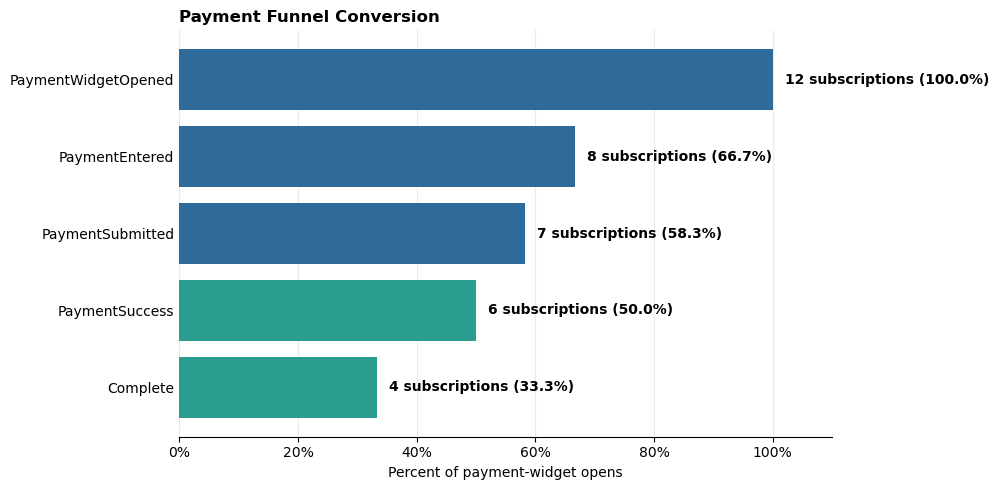

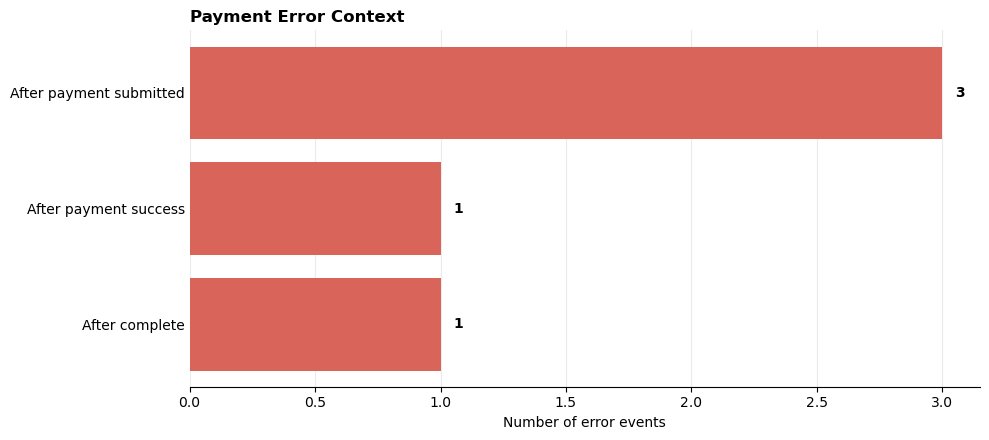

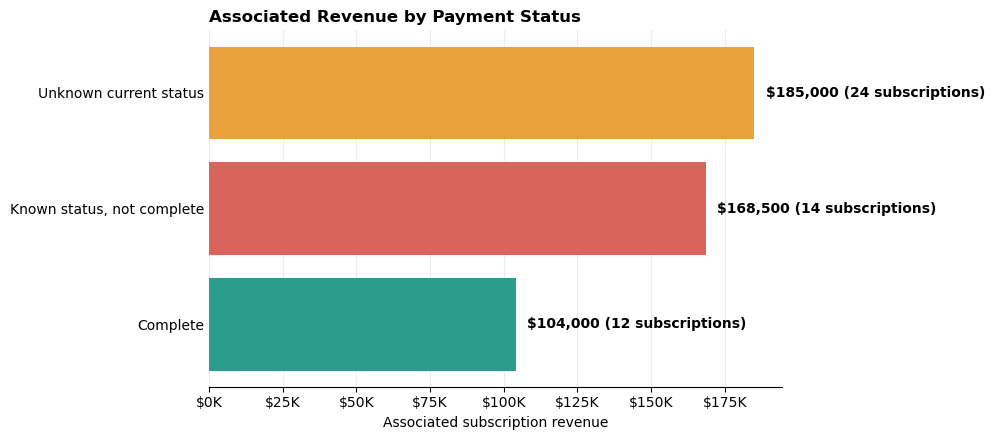

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, FuncFormatter

# Load data
DATA_DIR = Path(r"C:\Users\hooma\Downloads\tables")

subscriptions = pd.read_csv(DATA_DIR / "Subscriptions.csv")
status_log = pd.read_csv(DATA_DIR / "Payment_Status_Log.csv")
definitions = pd.read_csv(DATA_DIR / "Payment_Status_Definitions.csv")

status_log = status_log.merge(definitions, on="Status_ID", how="left")
status_log = status_log.sort_values(
    ["Subscription_ID", "Movement_Date", "Status_Movement_ID"]
)

# ---------- Chart 1: Payment funnel ----------
funnel = (
    status_log[status_log["Status_ID"].isin([1, 2, 3, 4, 5])]
    .groupby(["Status_ID", "Description"])["Subscription_ID"]
    .nunique()
    .rename("subscriptions")
    .reset_index()
    .sort_values("Status_ID")
)

funnel["conversion_rate"] = (
    funnel["subscriptions"] / funnel["subscriptions"].iloc[0]
)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#2F6B9A", "#2F6B9A", "#2F6B9A", "#2A9D8F", "#2A9D8F"]
bars = ax.barh(
    funnel["Description"],
    funnel["conversion_rate"],
    color=colors
)

ax.invert_yaxis()
ax.set_xlim(0, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Percent of payment-widget opens")
ax.set_title("Payment Funnel Conversion", loc="left", fontweight="bold")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

for bar, count, rate in zip(
    bars, funnel["subscriptions"], funnel["conversion_rate"]
):
    ax.text(
        rate + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{count} subscriptions ({rate:.1%})",
        va="center",
        fontweight="bold"
    )

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()


# ---------- Chart 2: Error context ----------
status_log["previous_status_id"] = (
    status_log.groupby("Subscription_ID")["Status_ID"].shift()
)

error_context = (
    status_log[status_log["Status_ID"] == 0]
    .assign(
        error_context=lambda x: x["previous_status_id"].map({
            2: "After payment entered",
            3: "After payment submitted",
            4: "After payment success",
            5: "After complete"
        }).fillna("Unknown / no prior event")
    )
    .groupby("error_context")
    .agg(
        error_events=("Subscription_ID", "size"),
        affected_subscriptions=("Subscription_ID", "nunique")
    )
    .reset_index()
    .sort_values("error_events", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 4.5))

bars = ax.barh(
    error_context["error_context"],
    error_context["error_events"],
    color="#D96459"
)

ax.set_title("Payment Error Context", loc="left", fontweight="bold")
ax.set_xlabel("Number of error events")
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

for bar, count in zip(bars, error_context["error_events"]):
    ax.text(
        count + 0.05,
        bar.get_y() + bar.get_height() / 2,
        str(count),
        va="center",
        fontweight="bold"
    )

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()


# ---------- Chart 3: Revenue exposure ----------
subscriptions["Current Payment Status"] = pd.to_numeric(
    subscriptions["Current Payment Status"],
    errors="coerce"
)

revenue_exposure = (
    subscriptions.assign(
        payment_status_group=lambda x: x["Current Payment Status"].map(
            lambda status: (
                "Unknown current status" if pd.isna(status)
                else "Complete" if status == 5
                else "Known status, not complete"
            )
        )
    )
    .groupby("payment_status_group")
    .agg(
        subscriptions=("Subscription ID", "count"),
        associated_revenue=("Revenue", "sum")
    )
    .reindex([
        "Complete",
        "Known status, not complete",
        "Unknown current status"
    ])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4.5))

colors = ["#2A9D8F", "#D96459", "#E9A23B"]
bars = ax.barh(
    revenue_exposure["payment_status_group"],
    revenue_exposure["associated_revenue"],
    color=colors
)

ax.set_title("Associated Revenue by Payment Status", loc="left", fontweight="bold")
ax.set_xlabel("Associated subscription revenue")
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1000:,.0f}K")
)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)

for bar, revenue, count in zip(
    bars,
    revenue_exposure["associated_revenue"],
    revenue_exposure["subscriptions"]
):
    ax.text(
        revenue + 4000,
        bar.get_y() + bar.get_height() / 2,
        f"${revenue:,.0f} ({count} subscriptions)",
        va="center",
        fontweight="bold"
    )

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()
plt.savefig(
    "payment_funnel_conversion.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)
plt.show()
# Chart 1
plt.savefig("payment_funnel_conversion.png", dpi=300, bbox_inches="tight", facecolor="white")

# Chart 2
plt.savefig("payment_error_context.png", dpi=300, bbox_inches="tight", facecolor="white")

# Chart 3
plt.savefig("payment_revenue_exposure.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "payment_funnel_conversion.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "payment_error_context.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "payment_revenue_exposure.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()